# Mini-taller 2 — Transformaciones homogéneas, tramas 3D y operación del robot MELFA (jog)

Presentado por:

*   Daniel Cartagena
*   Julian Zambrano
*   Edwin Vela






Este cuaderno sirve como **guía de documentación** y **plantilla de trabajo** para el Mini-taller 2.

## Objetivos
1. Construir matrices de transformación homogénea 4x4 (SE(3)) para robots RR, PR, RP, RPR y para el robot Mitsubishi **MELFA**.
2. Visualizar **tramas** (sistemas de coordenadas) en 3D.
3. Conectar teoría y práctica: **mapeo entre espacio articular y espacio de la tarea** usando el teach pendant en modo **jog**.

## Requisitos
- Python 3
- `numpy`, `matplotlib`

> Nota: El profesor mostrará el uso básico del teach pendant y explicará en clase la idea general de cinemática inversa para un robot de 6 GDL con muñeca esférica.


In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (activa proyección 3D)

np.set_printoptions(precision=4, suppress=True)

import sympy as sp
from sympy import init_printing, symbols, Integral
from sympy import trigsimp
init_printing(use_latex=True)

###
#funcion para graficar tomada del profe

def plot_frames_xy(T_list, axis_length=0.1, link_tol=1e-9, show=True, ax=None):

    # ---- Normalización de entrada ----
    T_arr = np.asarray(T_list)
    if T_arr.ndim != 3 or T_arr.shape[1:] != (4,4):
        raise ValueError("T_list debe ser de forma (N,4,4).")
    N = T_arr.shape[0]

    # ---- Preparar ejes ----
    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(3,3))
        created_ax = True

    origins = T_arr[:, :2, 3]    # orígenes
    x_dirs  = T_arr[:, :2, 0]    # ejes X
    y_dirs  = T_arr[:, :2, 1]    # ejes Y

    # ---- Dibujar eslabones ----
    for i in range(1, N):
        p_prev = origins[i-1]
        p_curr = origins[i]
        if np.linalg.norm(p_curr - p_prev) > link_tol:
            ax.plot([p_prev[0], p_curr[0]], [p_prev[1], p_curr[1]], 'k-')

    # ---- Dibujar ejes y etiquetas ----
    for i in range(N):
        ox, oy = origins[i]
        dx, dy = axis_length * x_dirs[i]
        ux, uy = axis_length * y_dirs[i]

        # Eje X
        ax.quiver(ox, oy, dx, dy, angles='xy', scale_units='xy', scale=1.0, color='r')
        ax.text(ox + dx, oy + dy, f"X{i}", color='r',
                fontsize=9, ha='left', va='center')

        # Eje Y
        ax.quiver(ox, oy, ux, uy, angles='xy', scale_units='xy', scale=1.0, color='g')
        ax.text(ox + ux, oy + uy, f"Y{i}", color='g',
                fontsize=9, ha='left', va='center')

    # ---- Decoración ----
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle=':', linewidth=0.8)

    all_pts = np.vstack([origins,
                         origins + axis_length * x_dirs,
                         origins + axis_length * y_dirs])
    min_xy = all_pts.min(axis=0)
    max_xy = all_pts.max(axis=0)
    span = max(max_xy - min_xy)
    if span == 0:
        span = axis_length * 2
    center = (min_xy + max_xy) / 2.0
    margin = 0.15 * span
    ax.set_xlim(center[0] - span/2 - margin, center[0] + span/2 + margin)
    ax.set_ylim(center[1] - span/2 - margin, center[1] + span/2 + margin)
    ax.set_title('Tramas del Robot 2D')

    if show and created_ax:
        plt.show()

    return ax

## 1) Utilidades de transformaciones (SE(3))

En robótica, una transformación homogénea 4x4 representa simultáneamente:

- **Rotación** (matriz 3x3) entre tramas
- **Traslación** (vector 3x1) entre orígenes

Forma general:

$$T = \begin{bmatrix}R & p\\ 0 & 1\end{bmatrix}$$

donde:
- R es la rotación (3x3),
- p es la posición (3x1) del origen de la trama “nueva” expresada en la trama “vieja”.

A continuación se definen rotaciones elementales alrededor de los ejes X, Y, Z y una traslación.


In [ ]:
# --------------------------
# Utilidades de transformaciones (SE(3))
# --------------------------
def Rx(theta: float) -> np.ndarray:
    c, s = np.cos(theta), np.sin(theta)
    T = np.eye(4)
    T[:3, :3] = np.array([[1, 0, 0],
                          [0, c, -s],
                          [0, s,  c]])
    return T

def Ry(theta: float) -> np.ndarray:
    c, s = np.cos(theta), np.sin(theta)
    T = np.eye(4)
    T[:3, :3] = np.array([[ c, 0, s],
                          [ 0, 1, 0],
                          [-s, 0, c]])
    return T

def Rz(theta: float) -> np.ndarray:
    c, s = np.cos(theta), np.sin(theta)
    T = np.eye(4)
    T[:3, :3] = np.array([[c, -s, 0],
                          [s,  c, 0],
                          [0,  0, 1]])
    return T

def Trans(x=0.0, y=0.0, z=0.0) -> np.ndarray:
    T = np.eye(4)
    T[0, 3], T[1, 3], T[2, 3] = x, y, z
    return T


## 2) Plot de tramas en 3D (RGB)

Esta función dibuja una lista de transformaciones homogéneas (N,4,4) como tramas en 3D:
- Eje X en rojo
- Eje Y en verde
- Eje Z en azul

Además dibuja segmentos negros entre los orígenes consecutivos (útil para visualizar eslabones).


In [ ]:
# --------------------------
# Plot de tramas en 3D (RGB)
# --------------------------
def plot_frames_3d(T_list, axis_length=0.1, link_tol=1e-12, ax=None, show=True, title=None):
    """
    Dibuja tramas 3D a partir de una lista/array (N,4,4) de matrices homogéneas (SE(3)).
    - Eje X (rojo), Y (verde), Z (azul) con etiquetas Xi, Yi, Zi en la punta.
    - Segmentos negros entre orígenes consecutivos (eslabones) si hay traslación.
    """
    T_arr = np.asarray(T_list)
    if T_arr.ndim != 3 or T_arr.shape[1:] != (4, 4):
        raise ValueError("T_list debe ser de forma (N,4,4).")

    created_ax = False
    if ax is None:
        fig = plt.figure(figsize=(7, 7))
        ax = fig.add_subplot(111, projection='3d')
        created_ax = True

    # Origen y ejes locales
    origins = T_arr[:, :3, 3]   # (N, 3)
    x_dirs  = T_arr[:, :3, 0]   # (N, 3) eje X local
    y_dirs  = T_arr[:, :3, 1]   # (N, 3) eje Y local
    z_dirs  = T_arr[:, :3, 2]   # (N, 3) eje Z local

    # Dibujar ejes y etiquetas
    for i in range(T_arr.shape[0]):
        ox, oy, oz = origins[i]
        dx, dy, dz = axis_length * x_dirs[i]
        ux, uy, uz = axis_length * y_dirs[i]
        wx, wy, wz = axis_length * z_dirs[i]

        ax.quiver(ox, oy, oz, dx, dy, dz, length=1.0, normalize=False, color='r')
        ax.text(ox + dx, oy + dy, oz + dz, f"X{i}", color='r', fontsize=9)

        ax.quiver(ox, oy, oz, ux, uy, uz, length=1.0, normalize=False, color='g')
        ax.text(ox + ux, oy + uy, oz + uz, f"Y{i}", color='g', fontsize=9)

        ax.quiver(ox, oy, oz, wx, wy, wz, length=1.0, normalize=False, color='b')
        ax.text(ox + wx, oy + wy, oz + wz, f"Z{i}", color='b', fontsize=9)

    # Eslabones (segmentos negros entre orígenes)
    for i in range(1, origins.shape[0]):
        p0 = origins[i - 1]
        p1 = origins[i]
        if np.linalg.norm(p1 - p0) > link_tol:
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], 'k-')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # Encajar límites alrededor de todas las puntas y orígenes
    all_pts = np.vstack([
        origins,
        origins + axis_length * x_dirs,
        origins + axis_length * y_dirs,
        origins + axis_length * z_dirs
    ])
    mins = all_pts.min(axis=0)
    maxs = all_pts.max(axis=0)
    center = (mins + maxs) / 2.0
    span = (maxs - mins).max()
    if span <= 0:
        span = axis_length * 2
    margin = 0.2 * span
    ax.set_xlim(center[0] - span/2 - margin, center[0] + span/2 + margin)
    ax.set_ylim(center[1] - span/2 - margin, center[1] + span/2 + margin)
    ax.set_zlim(center[2] - span/2 - margin, center[2] + span/2 + margin)

    # Aspecto cúbico
    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass

    if title:
        ax.set_title(title)

    if created_ax and show:
        plt.show()
    return ax


# 3) Convención Denavit–Hartenberg

Los **parámetros DH (Denavit–Hartenberg)** son una forma estandarizada de describir la **cinemática directa** de un robot serial. En lugar de escribir transformaciones arbitrarias entre cada par de eslabones, se define una secuencia de marcos y se resume cada unión mediante cuatro parámetros: ángulo articular $\theta$, desplazamiento $d$, longitud $a$ y torsión $\alpha$. Con esto se puede reconstruir la cinemática directa del robot de manera sistemática, compacta y programable.

## 3.1) Convención DH modificada (DH_mod)

En la **convención DH modificada (DH_mod, estilo Craig$, la transformación homogénea entre marcos consecutivos se expresa como

$$
A_i = R_x(\alpha_{i-1}),T_x(a_{i-1}),R_z(\theta_i),T_z(d_i),
$$

es decir, primero se aplican los parámetros geométricos asociados al eslabón previo ($a_{i-1}, \alpha_{i-1}$), y luego los asociados a la junta ($\theta_i, d_i$). Esta convención es especialmente cómoda para implementar cadenas cinemáticas en código y para modelar robots industriales con múltiples articulaciones rotacionales.

## 3.2) ¿Qué representa cada parámetro?

En DH_mod, cada fila de la tabla describe cómo pasar de una trama a la siguiente usando cuatro parámetros:

* $\theta_i$: rotación alrededor de $z_i$ (variable si la junta $i$ es rotacional).
* $d_i$: desplazamiento a lo largo de $z_i$ (variable si la junta $i$ es prismática).
* $a_{i-1}$: desplazamiento a lo largo de $x_{i-1}$ (longitud de la normal común entre ejes $z$).
* $\alpha_{i-1}$: rotación alrededor de $x_{i-1}$ para alinear $z_{i-1}$ con $z_i$.

> **Idea clave:** en DH/DH_mod, los parámetros no describen necesariamente “la forma física” de la pieza como uno la ve, sino la **relación geométrica entre marcos**.

## 3.3) Regla práctica más importante: ¿cuándo una distancia va por (x) y cuándo por (z)?

Esta es una de las dudas más comunes (y muy importante). La decisión **no se toma por la apariencia del eslabón físico**, sino por **la geometría entre ejes de junta**.

### Distancia sobre $x\rightarrow a_{i-1}$

Una distancia va en $a_{i-1}$ cuando corresponde a la **separación perpendicular entre los ejes $z_{i-1}$ y $z_i$, medida sobre la **normal común** a esos dos ejes. Esa normal define precisamente el eje $x_{i-1}$.

En otras palabras:

* si para “ir” de un eje de junta al siguiente necesitas moverte **perpendicularmente al eje de la junta**, esa distancia normalmente aparece en $a$;
* esto suele coincidir con lo que intuitivamente se llama “longitud del eslabón” en muchos robots (por ejemplo, $L_2$, $L_3$).

### Distancia sobre $z\rightarrow d_i$

Una distancia va en $d_i$ cuando corresponde a un **offset a lo largo del eje de la junta** (es decir, a lo largo de $z_i$).

En otras palabras:

* si la separación entre marcos ocurre **siguiendo la dirección del eje de la articulación**, esa distancia aparece en $d$;
* esto es común en alturas de base, offsets entre muñecas o herramientas, y tramas del efector final.

### Lo que suele causar la confusión

Es frecuente escuchar que “el eslabón va sobre $x$”, porque $a$ se mide sobre $x$. Eso es útil como guía, pero **no significa que toda pieza física deba quedar alineada con $x$. En muchos casos, una parte visible del robot queda mejor representada como un offset en $d$ (sobre $z$).

Por ejemplo:

* una **altura de base** suele aparecer como $d$,
* una **extensión de herramienta** puede quedar sobre $z$ de la herramienta (también como $d$),
* mientras que las longitudes “de brazo” entre ejes suelen aparecer como $a$.

## 3.4) ¿Cómo se obtuvieron los parámetros para el MELFA del laboratorio?

Los parámetros a continuación para el robot **MELFA del laboratorio** se obtienen fijando marcos sobre el robot de forma consistente con DH_mod:

1. **Se identifica el eje de cada junta** como eje $z_i$.
2. **Se define $x_{i-1}$ sobre la normal común entre $z_{i-1}$ y $z_i$ (cuando existe de forma única).
3. **Se eligen orígenes** de los marcos de manera consistente y conveniente para simplificar offsets.
4. **Se leen** las distancias $(a,d)$ y giros ($\alpha,\theta$) según esa elección.

Una forma de representarlos es:

| $i$           | $\theta_i$ | $d_i$ | $a_{i-1}$ | $\alpha_{i-1}$ |
| ------------- | ---------- | ----- | --------- | -------------- |
| $1$           | $q_1$      | $L_1$ | $0.0$     | $0.0$          |
| $2$           | $q_2$      | $0.0$ | $0.0$     | $-\pi/2$       |
| $3$           | $q_3$      | $0.0$ | $L_2$     | $0.0$          |
| $4$           | $q_4$      | $0.0$ | $L_3$     | $\pi/2$        |
| $5$           | $q_5$      | $0.0$ | $0.0$     | $-\pi/2$       |
| $6$           | $q_6$      | $0.0$ | $0.0$     | $\pi/2$        |
| $\mathrm{EF}$ | $0.0$      | $L_4$ | $0.0$     | $0.0$          |

## 3.5) Lectura geométrica de esta tabla (MELFA)

En esta tabla aparecen:

* $q_1,\dots,q_6$ como variables articulares en $\theta_i$ (robot 6R, seis juntas rotacionales),
* $L_1$ como altura/base (**offset sobre $z$ en la primera fila, por eso aparece en $d_1$),
* $L_2, L_3$ como longitudes principales de brazo (aparecen en $a$ porque representan separaciones entre ejes medidas sobre la normal común),
* $\pm \pi/2$ en $\alpha_{i-1}$ cuando dos ejes consecutivos son ortogonales (no apuntan en la misma dirección),
* y varios **0.0** cuando los ejes se intersectan, son coaxiales o se escogieron orígenes sin offset adicional.

### Comentario importante sobre $L_1$ y la fila EF

Puede parecer extraño que algunos “tramos físicos” (como la base o la herramienta) no aparezcan en $a$ sino en $d$. **Esto no es un error**: la convención lo contempla completamente.

* En la primera fila, $L_1$ aparece en $d_1$ porque corresponde a una **separación a lo largo del eje de la primera junta** (dirección (z)).
* En la fila **EF**, $L_4$ aparece en $d$ porque la trama del efector final se eligió de modo que la longitud útil de herramienta/brida quede **alineada con su eje $z$.

Es decir, la pregunta correcta no es “¿la pieza física se ve horizontal o vertical?”, sino:

> **¿la separación entre estas dos tramas está ocurriendo a lo largo del eje $x$ (normal común) o a lo largo del eje $z$ (eje de junta / herramienta)?**

## 3.6) Sobre la fila EF (efector final)

La fila **EF** no es una junta real, sino una **trama adicional del efector final** (tool frame) añadida para representar la geometría de la brida/herramienta (en la tabla, con un offset $L_4$). Esto permite que la cadena cinemática entregue directamente la pose de una referencia útil para simulación, programación o control.

Así, la cadena completa permite reconstruir la postura del MELFA en el laboratorio de forma compacta y programable, incluso si el modelo es una aproximación geométrica (muy útil para docencia y simulación) y no necesariamente el modelo CAD/fábrica exacto.

In [ ]:
def make_chain_MELFA(q_1, q_2, q_3, q_4, q_5, q_6, L1, L2, L3, L4):
    """
    Cadena de 5 tramas {0}..{7} usando DH_mod (Craig).

    Convención DH_mod (Craig):
        A_i = Rx(alpha_{i-1}) @ Tx(a_{i-1}) @ Rz(theta_i) @ Tz(d_i)

    Retorna:
        Ts: array (5,4,4) con [T0, T1, T2, T3, T4, TEF]
            donde Ti = T0_i.
    """
    import numpy as np

    def _rotz(th):
        c, s = np.cos(th), np.sin(th)
        T = np.eye(4)
        T[:3, :3] = np.array([[c, -s, 0],
                              [s,  c, 0],
                              [0,  0, 1]])
        return T

    def _rotx(al):
        c, s = np.cos(al), np.sin(al)
        T = np.eye(4)
        T[:3, :3] = np.array([[1, 0,  0],
                              [0, c, -s],
                              [0, s,  c]])
        return T

    def _transx(a):
        T = np.eye(4)
        T[0, 3] = a
        return T

    def _transz(d):
        T = np.eye(4)
        T[2, 3] = d
        return T

    def _A_mdh(alpha_prev, a_prev, theta_i, d_i):
        # Craig MDH
        return _rotx(alpha_prev) @ _transx(a_prev) @ _rotz(theta_i) @ _transz(d_i)

    thetas  = [q_1,      q_2,  q_3,      q_4,      q_5,      q_6,  0.0]
    ds      = [L1,       0.0,  0.0,      0.0,      0.0,      0.0,  L4 ]
    a_prevs = [0.0,      0.0,   L2,       L3,      0.0,      0.0,  0.0]
    alphas  = [0.0, -np.pi/2,  0.0,  -np.pi/2, np.pi/2, -np.pi/2,  0.0]

    T0 = np.eye(4)
    Ts = [T0]
    T = T0.copy()

    for th, d, a, al in zip(thetas, ds, a_prevs, alphas):
        T = T @ _A_mdh(al, a, th, d)
        Ts.append(T)

    return np.stack(Ts, axis=0)

T0_1  =
[[1.   0.   0.   0.  ]
 [0.   1.   0.   0.  ]
 [0.   0.   1.   0.15]
 [0.   0.   0.   1.  ]]
T0_E (T0_4) =
[[ 0.5    -0.7071  0.5     0.4871]
 [-0.5    -0.7071 -0.5    -0.075 ]
 [ 0.7071 -0.     -0.7071  0.2561]
 [ 0.      0.      0.      1.    ]]


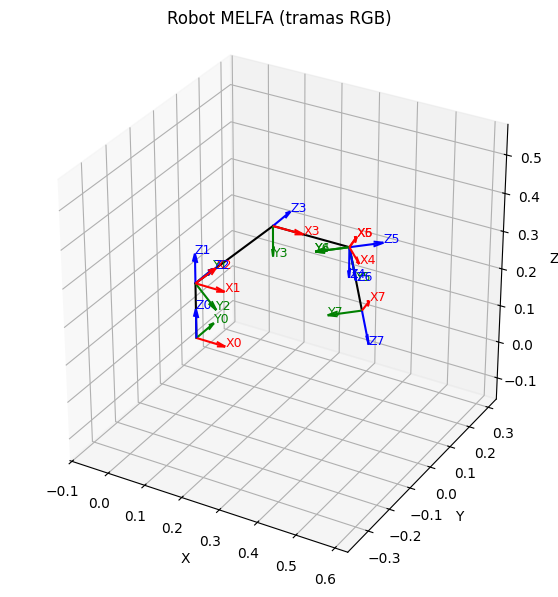

<Axes3D: title={'center': 'Robot MELFA (tramas RGB)'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
# --------------------------
# Demostración rápida
# --------------------------
L1, L2, L3, L4 = 0.15, 0.30, 0.20, 0.15

q_1 = np.deg2rad(0)    # Z
q_2 = np.deg2rad(-45)    # Y
q_3 = np.deg2rad(45)    # Y
q_4 = np.deg2rad(45)    # z
q_5 = np.deg2rad(-45)    # Y
q_6 = np.deg2rad(0)    # z

Ts = make_chain_MELFA(q_1, q_2, q_3, q_4, q_5, q_6, L1, L2, L3, L4)

print("T0_1  =")
print(Ts[1])


print("T0_E (T0_4) =")
print(Ts[-1])

plot_frames_3d(Ts, axis_length=0.08, title="Robot MELFA (tramas RGB)")


## 4) Cinemática inversa del Mitsubishi MELFA (6 GDL, muñeca esférica)

Esta sección explica el **procedimiento estándar** (analítico/geométrico) para resolver la cinemática inversa de un robot industrial de 6 GDL con **muñeca esférica** (Los ejes de las últimas 3 articulaciones se intersectan en un punto).

> Idea principal: separar el problema en dos partes:
> 1) **Posición** del centro de muñeca con $q_1$, $q_2$, $q_3$  
> 2) **Orientación** del efector final con $q_4$, $q_5$, $q_6$

### 4.1 Notación mínima
- $T_0^E$: transformación deseada desde base {0} hasta efector final {E}.
- $R_0^E$: rotación (3x3) de $T_0^E$.
- $p_0^E$: posición (3x1) del origen de {E} expresada en {0}.
- $p_6^E$: vector desde el origen de la trama {6} (brida/muñeca) hasta {E} expresado en la trama {6}.  
  (Este vector depende de la herramienta: TCP, extensión, etc.)

### 4.2 Paso 1 — Centro de muñeca (wrist center)
Si la muñeca esférica existe, entonces el origen de la trama {6} (o centro de muñeca, según convención) se puede obtener “retrayendo” el efector final:

$p_0^W = p_0^E$ − $R_0^Ep_6^E$

Interpretación:
- $p_0^E$ es “donde quieres el TCP”.
- $R_0^E$ te dice hacia dónde está orientado.
- $p_6^E$ indica cuánto hay que retroceder desde el TCP hasta la muñeca a lo largo de la orientación deseada.

En robots típicos, $p_6^E$ suele ser un desplazamiento a lo largo del eje Z de la herramienta/brida, pero debes usar el que corresponda a tu definición de {6} y {E}.

### 4.3 Paso 2 — Resolver $q_1, q_2, q_3$ (posición)
Una vez conoces $p_0^W$, el objetivo es encontrar $q_1$, $q_2$, $q_3$ para ubicar ese punto.

En muchos robots industriales:
- $q_1$ define el giro alrededor del eje Z de la base, fijando el plano de trabajo donde quedará el brazo.
- $q_2$ y $q_3$ forman un mecanismo equivalente a un robot tipo RR en ese plano (con longitudes y offsets propios del robot).

Procedimiento geométrico típico:
1) Proyecta $p_0^W$ en el plano XY para encontrar el ángulo de base ($q_1$).
2) Lleva el problema al plano del brazo (después de $q_1$) y resuelve el triángulo definido por:
   - distancia desde el “hombro” al centro de muñeca,
   - longitudes efectivas del brazo y antebrazo,
   - offsets si existen.
3) De aquí salen $q_2$ y $q_3$, usualmente con al menos dos configuraciones: “codo arriba” y “codo abajo”.

Resultado importante: esta etapa ya genera **múltiples soluciones** (por lo general 2).

### 4.4 Paso 3 — Orientación: resolver $q_4$, $q_5$, $q_6$
Con $q_1$, $q_2$, $q_3$ calculados, puedes obtener $R_0^3$ (rotación desde base hasta la trama 3).

Luego:

$R_3^6 = (R_0^3)^TR_0^E$

$R_3^6$ es la rotación que deben “hacer” las últimas tres articulaciones (La muñeca) para lograr la orientación deseada.

Ahora se extraen $q_4$, $q_5$,y $q_6$ a partir de $R_3^6$, usando la convención de rotaciones que corresponda al robot (por ejemplo, una descomposición tipo ZYZ, XYZ, etc., según cómo se haya modelado la muñeca).

En una muñeca esférica aparecen típicamente:
- dos soluciones para orientación (dependiendo del signo asociado a senos/cosenos),
- y singularidades cuando el ángulo intermedio (por ejemplo $q_5$) se acerca a 0 o a pi, porque se pierde un grado de libertad (gimbal lock).

### 4.5 Paso 4 — Verificación (siempre)
Cualquier solución candidata ($q_1$ a $q_6$) debe verificarse con cinemática directa:

$T_0^E(q)$ debe aproximar la $T_0^E$ deseada (posición y orientación dentro de tolerancia).

### 4.6 Comentarios prácticos para laboratorio
- El teach pendant reporta lecturas en espacio articular (J1…J6) y en espacio de tarea (X,Y,Z y orientación).  
- Es clave que anotes también el “modo” o convención de orientación (cómo la presenta el teach) y el TCP activo.
- En el mini-taller se trabajará solo con **jog** (articular y cartesiano), y el objetivo es documentar el mapeo entre ambos espacios.


## 5) Enunciados del Mini-taller 2 (30 pts)

### Ejercicio 1 (10 pts) — Transformaciones 4x4 para RR, PR, RP, RPR y Melfa
Para cada robot RR, PR, RP, RPR y Melfa:
1) Defina tramas {0}, {1}, …, {E}.
2) Obtenga las matrices homogéneas entre tramas consecutivas y la transformación total $T_0^E$.  
3) Evalúe y grafique $T_0^E$ en 4 configuraciones diferentes (numéricas).

### Ejercicio 2 (10 pts) — Visualización 3D de tramas
Para RR, PR, RP, RPR y MELFA:
- Grafique en 3D las tramas (mínimo base y efector final; idealmente intermedias).
- Use al menos una configuración representativa por robot.

### Ejercicio 3 (10 pts) — Laboratorio con teach pendant (modo jog)
Para el MELFA:
1) Alcance 4 objetivos (que se indicarán en clase) en la estación.  
2) Para cada objetivo, llegue por jog en espacio de la tarea  
3) Registre en una tabla:
   - posición y orientación en tarea (según reporte del teach)  
   - evidencia fotográfica por objetivo  
4) Obtenga usando la cinemática inversa del Melfa los valores articulares de cada una de los 4 objetivos.
4) Verifique con cinemática directa los 4 objetivos y reporte el error.

**Entregables:** informe PDF + código (.ipynb)

#1. y 2.


## RR
Matrices de transformación homogenea:

$$T_0^1 = \begin{bmatrix} Cos(\theta_1) & -Sen(\theta_1) & 0 & 0 \\ Sen(\theta_1) & Cos(\theta_1) & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1
\end{bmatrix}$$

$$T_1^2 = \begin{bmatrix} Cos(\theta_2) & -Sen(\theta_2) &0 & L_1 \\ Sen(\theta_2) & Cos(\theta_2) & 0 & 0\\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1
\end{bmatrix}$$

$$T_2^{EF} = \begin{bmatrix} 1 & 0 & 0 &L_2 \\ 0 & 1 & 0 & 0\\ 0 & 0 & 1 & 0\\ 0 & 0 & 0 & 1
\end{bmatrix}$$

Multiplicamos para hallar la cinemática directa del EF respecto al origen (0):
$$T_0^{EF} = T_0^1 \cdot T_1^2\cdot T_2^{EF}$$

In [ ]:
theta1 = sp.symbols('theta1')
T_01 = sp.Matrix([
    [sp.cos(theta1), -sp.sin(theta1), 0, 0],
    [sp.sin(theta1),  sp.cos(theta1), 0 ,0],
    [0, 0, 1 , 0],
    [0, 0, 0, 1]
])
theta2, L1 = sp.symbols('theta2 L1')
T_12 = sp.Matrix([
    [sp.cos(theta2), -sp.sin(theta2), 0 ,L1],
    [sp.sin(theta2),  sp.cos(theta2), 0 , 0],
    [0, 0, 1 , 0],
    [0, 0, 0, 1]
])

L2 = sp.symbols('L2')
T_2EF = sp.Matrix([
    [1, 0, 0,L2],
    [0, 1, 0, 0],
    [0, 0, 1 ,0],
    [0, 0, 0, 1]
])
print("Matriz homogenea del origen al efector final:")
Tf=trigsimp(T_01*T_12*T_2EF)
display(Tf)

Matriz homogenea del origen al efector final:


⎡cos(θ₁ + θ₂)  -sin(θ₁ + θ₂)  0  L₁⋅cos(θ₁) + L₂⋅cos(θ₁ + θ₂)⎤
⎢                                                            ⎥
⎢sin(θ₁ + θ₂)  cos(θ₁ + θ₂)   0  L₁⋅sin(θ₁) + L₂⋅sin(θ₁ + θ₂)⎥
⎢                                                            ⎥
⎢     0              0        1               0              ⎥
⎢                                                            ⎥
⎣     0              0        0               1              ⎦

In [ ]:
# -------------------------------------------------
# Funciones auxiliares
# -------------------------------------------------
def Tz(R, t):
    T = np.eye(4)
    T[:3,:3] = R
    T[:3, 3] = t
    return T

def Rz(theta):
    c, s = np.cos(theta), np.sin(theta)
    R = np.eye(3)
    R[0,0], R[0,1] = c, -s
    R[1,0], R[1,1] = s,  c
    return R

def fk_rr(theta1, theta2, L1, L2):
    T0 = np.eye(4)
    T1 = Tz(Rz(theta1), np.array([0,0,0]))
    T2 = T1 @ Tz(np.eye(3), np.array([L1,0,0]))
    T3 = T2 @ Tz(Rz(theta2), np.array([0,0,0]))
    T4 = T3 @ Tz(np.eye(3), np.array([L2,0,0]))
    return np.stack([T0, T1, T2, T3, T4], axis=0)

# -------------------------------------------------
# Parámetros
# -------------------------------------------------
L1 = 25
L2 = 20



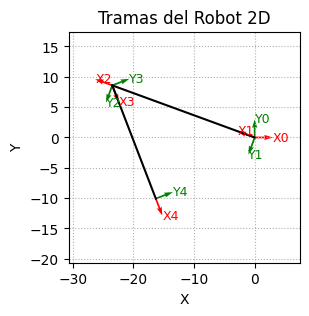

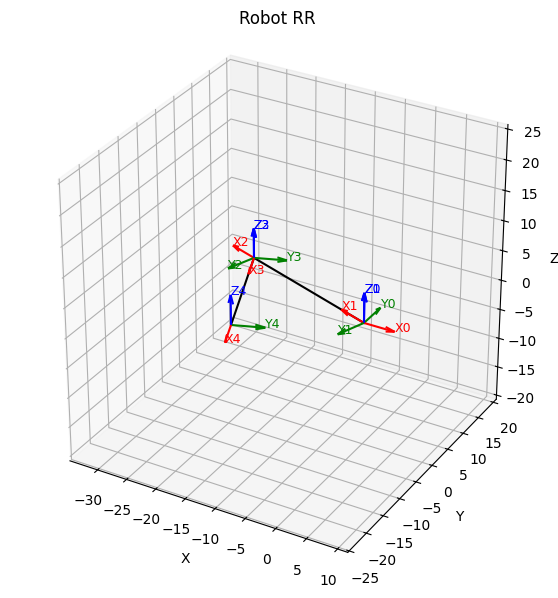

<Axes3D: title={'center': 'Robot RR '}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_rr(np.radians(np.random.uniform(0, 360)), np.radians(np.random.uniform(0, 360)), L1, L2)
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot RR ")

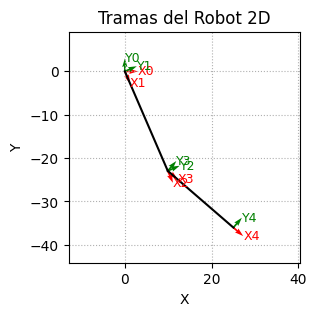

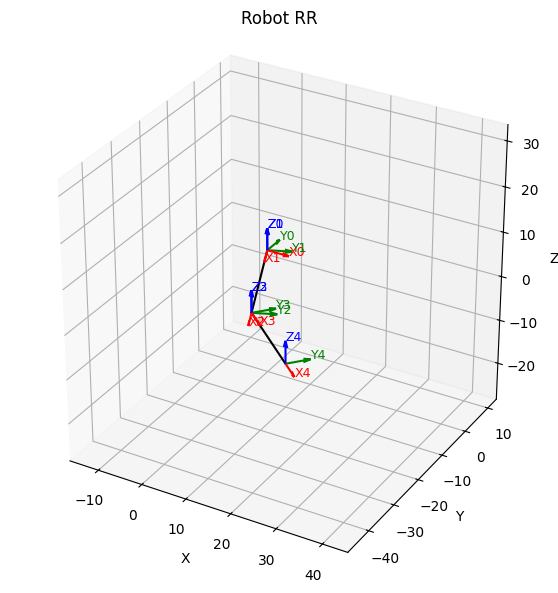

<Axes3D: title={'center': 'Robot RR'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_rr(np.radians(np.random.uniform(0, 360)), np.radians(np.random.uniform(0, 360)), L1, L2)
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot RR")

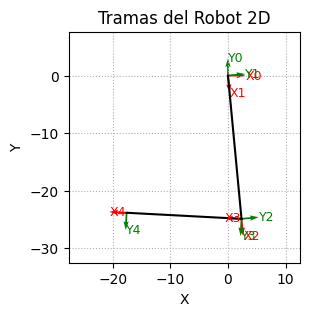

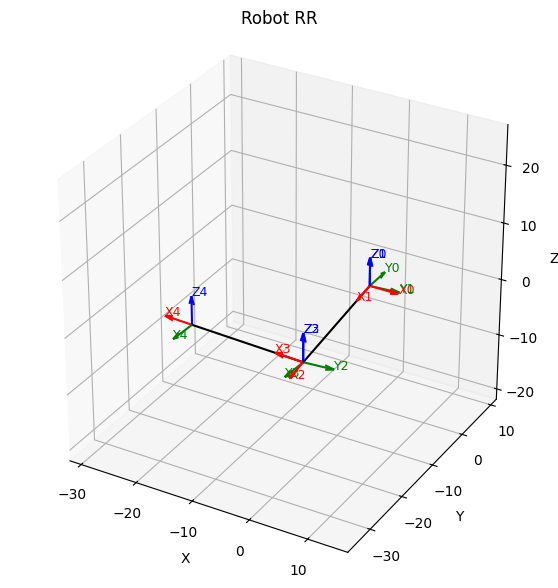

<Axes3D: title={'center': 'Robot RR'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_rr(np.radians(np.random.uniform(0, 360)), np.radians(np.random.uniform(0, 360)), L1, L2)
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot RR")

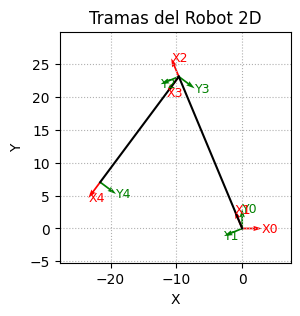

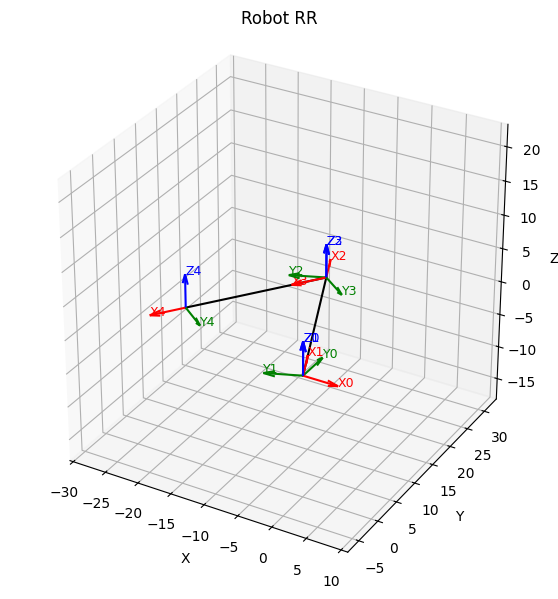

<Axes3D: title={'center': 'Robot RR'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_rr(np.radians(np.random.uniform(0, 360)), np.radians(np.random.uniform(0, 360)), L1, L2)
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot RR")

## PR
Matrices de transformación homogenea:


$$T_0^{1} = \begin{bmatrix} 1 & 0 & 0 & L_1 + \theta_1 \\ 0 & 1 & 0 & 0\\ 0 & 0 & 1 &0 \\ 0 & 0 & 0 & 1\end{bmatrix}$$

$$T_1^{2} = \begin{bmatrix} Cos(\theta_2) & -Sen(\theta_2) & 0 & 0\\ Sen(\theta_2) & Cos(\theta_2) & 0 & 0\\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1\end{bmatrix}$$

$$T_2^{EF} = \begin{bmatrix} 1 & 0 & 0 &L_2 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0\\ 0 & 0 & 0 & 1 \end{bmatrix}$$
Multiplicamos para hallar la cinemática directa del EF respecto al origen (0):
$$T_0^{EF} = T_0^1 \cdot T_1^2\cdot T_2^{EF}$$

In [ ]:
theta1, L1 = sp.symbols('theta1 L1')
T_01 = sp.Matrix([
    [1, 0, 0 ,L1+theta1],
    [0,  1, 0, 0],
    [0, 0, 1 , 0],
    [0, 0, 0, 1]
])
theta2 = sp.symbols('theta2')
T_12 = sp.Matrix([
    [sp.cos(theta2), -sp.sin(theta2), 0 , 0],
    [sp.sin(theta2),  sp.cos(theta2), 0 , 0],
    [0, 0, 1 , 0],
    [0, 0, 0, 1]
])

L2 = sp.symbols('L2')
T_2EF = sp.Matrix([
    [1, 0, 0 ,L2],
    [0, 1, 0 , 0],
    [0, 0, 1 , 0],
    [0, 0, 0, 1]
])
print("Matriz homogenea del origen al efector final:")
Tf=trigsimp(T_01*T_12*T_2EF)
display(Tf)

Matriz homogenea del origen al efector final:


⎡cos(θ₂)  -sin(θ₂)  0  L₁ + L₂⋅cos(θ₂) + θ₁⎤
⎢                                          ⎥
⎢sin(θ₂)  cos(θ₂)   0       L₂⋅sin(θ₂)     ⎥
⎢                                          ⎥
⎢   0        0      1           0          ⎥
⎢                                          ⎥
⎣   0        0      0           1          ⎦

In [ ]:
def fk_pr(d1, theta2, L2):

    T0 = np.eye(4)

    # Traslación prismática en X
    T1 = Tz(np.eye(3), np.array([d1, 0, 0]))

    # Rotación
    T2 = T1 @ Tz(Rz(theta2), np.array([0, 0, 0]))

    # Eslabón final
    T3 = T2 @ Tz(np.eye(3), np.array([L2, 0, 0]))

    return np.stack([T0, T1, T2, T3], axis=0)

# -------------------------------------------------
# Parámetro
# -------------------------------------------------
L2 = 20

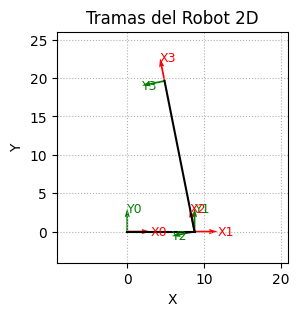

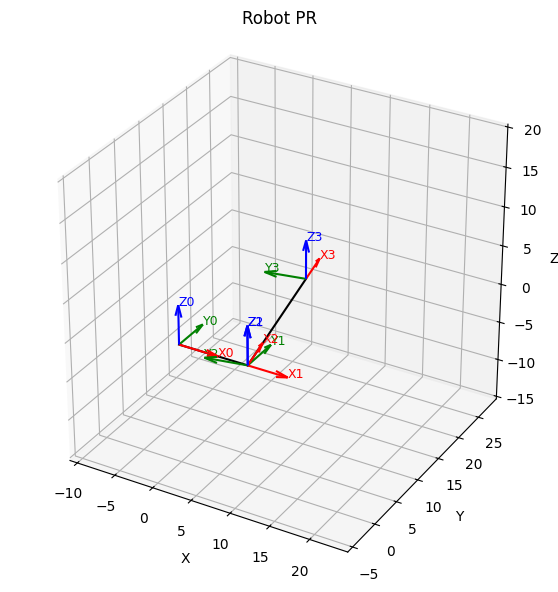

<Axes3D: title={'center': 'Robot PR'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_pr(np.random.uniform(0, 20), np.radians(np.random.uniform(0, 360)), L2)
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot PR")

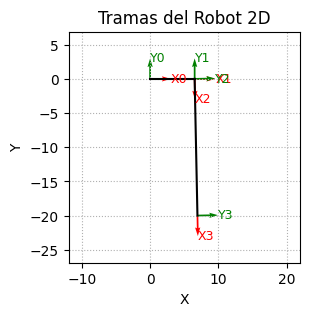

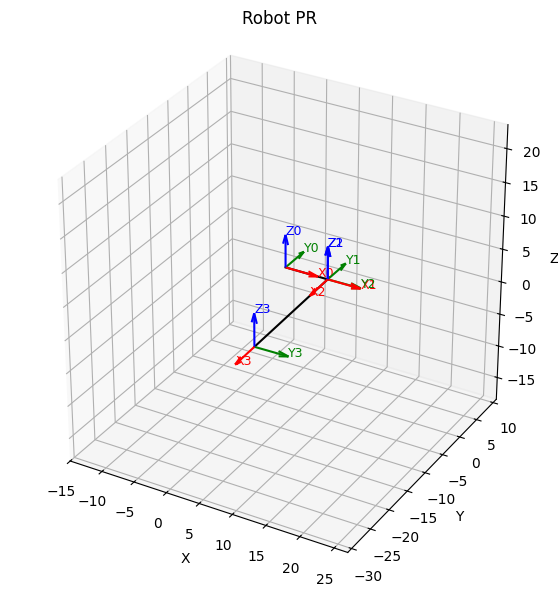

<Axes3D: title={'center': 'Robot PR'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_pr(np.random.uniform(0, 20), np.radians(np.random.uniform(0, 360)), L2)
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot PR")

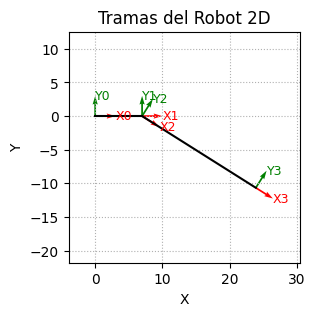

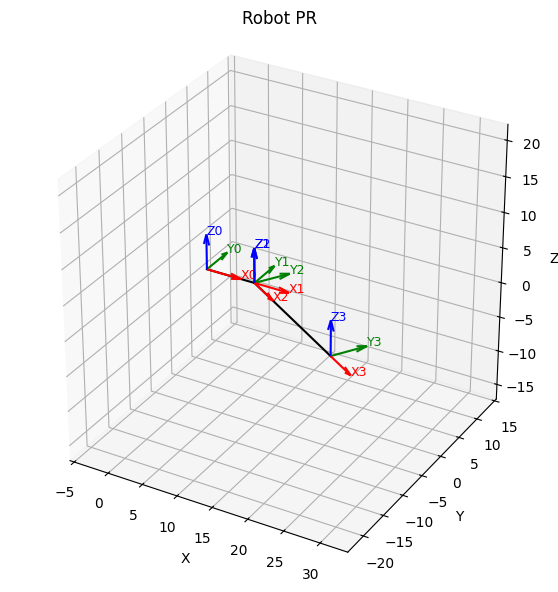

<Axes3D: title={'center': 'Robot PR'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_pr(np.random.uniform(0, 20), np.radians(np.random.uniform(0, 360)), L2)
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot PR")

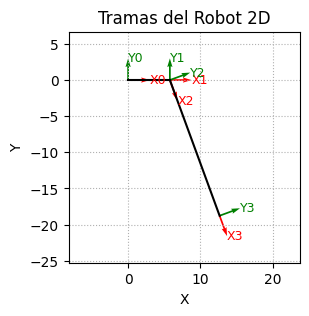

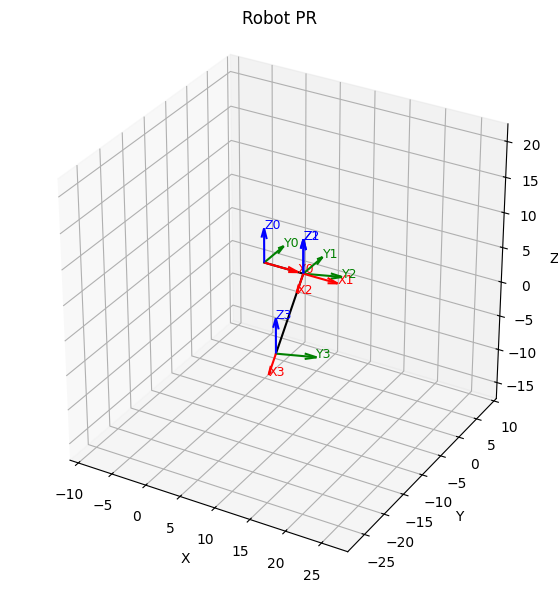

<Axes3D: title={'center': 'Robot PR'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_pr(np.random.uniform(0, 20), np.radians(np.random.uniform(0, 360)), L2)
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot PR")

## RP
Matrices de transformación homogenea:

$$T_0^1 = \begin{bmatrix} Cos(\theta_1) & -Sen(\theta_1) & 0 & 0\\ Sen(\theta_1) & Cos(\theta_1) & 0 & 0\\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1\end{bmatrix}$$

$$T_1^{EF} = \begin{bmatrix} 1 & 0 & 0 &L_1+\theta_2 \\ 0 & 1 & 0 & 0\\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1\end{bmatrix}$$


Multiplicamos para hallar la cinemática directa del EF respecto al origen (0):
$$T_0^{EF} = T_0^1 \cdot  T_1^{EF}$$

In [ ]:
theta1 = sp.symbols('theta1')
T_01 = sp.Matrix([
    [sp.cos(theta1), -sp.sin(theta1), 0 , 0],
    [sp.sin(theta1),  sp.cos(theta1), 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
theta2, L1 = sp.symbols('theta2 L1')
T_1EF = sp.Matrix([
    [1, 0, 0,L1+theta2],
    [0, 1, 0 , 0],
    [0, 0, 1 , 0],
    [0, 0, 0, 1]
])


print("Matriz homogenea del origen al efector final:")
Tf=trigsimp(T_01*T_1EF)
display(Tf)

Matriz homogenea del origen al efector final:


⎡cos(θ₁)  -sin(θ₁)  0  (L₁ + θ₂)⋅cos(θ₁)⎤
⎢                                       ⎥
⎢sin(θ₁)  cos(θ₁)   0  (L₁ + θ₂)⋅sin(θ₁)⎥
⎢                                       ⎥
⎢   0        0      1          0        ⎥
⎢                                       ⎥
⎣   0        0      0          1        ⎦

In [ ]:
def fk_rp(theta1, d2):

    T0 = np.eye(4)

    # Rotación
    T1 = Tz(Rz(theta1), np.array([0, 0, 0]))

    # Traslación prismática sobre X local
    T2 = T1 @ Tz(np.eye(3), np.array([d2, 0, 0]))

    return np.stack([T0, T1, T2], axis=0)



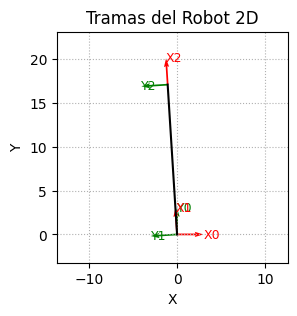

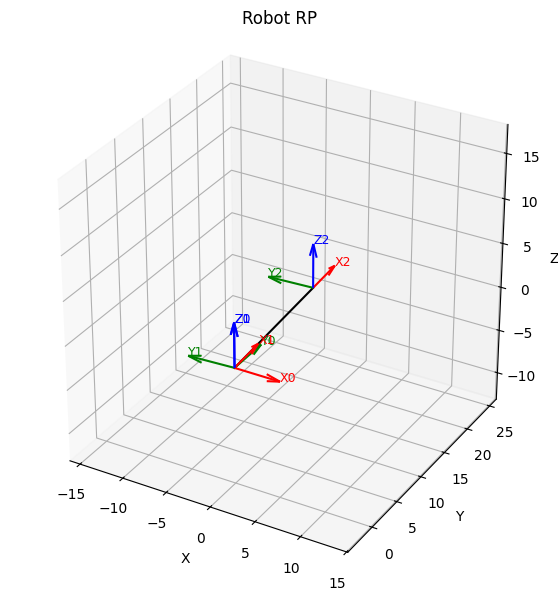

<Axes3D: title={'center': 'Robot RP'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_rp(np.radians(np.random.uniform(0, 360)), np.random.uniform(0, 20))
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot RP")

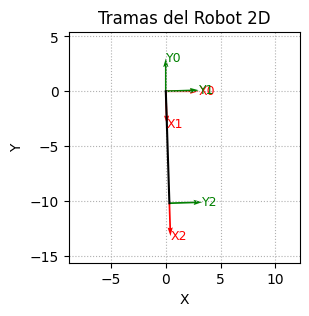

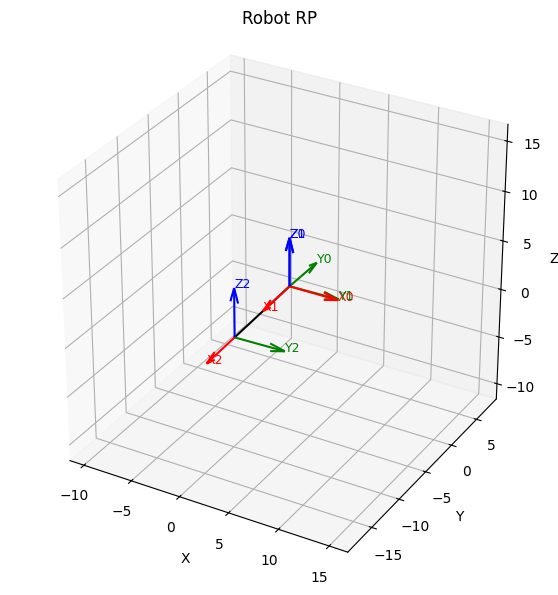

<Axes3D: title={'center': 'Robot RP'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_rp(np.radians(np.random.uniform(0, 360)), np.random.uniform(0, 20))
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot RP")

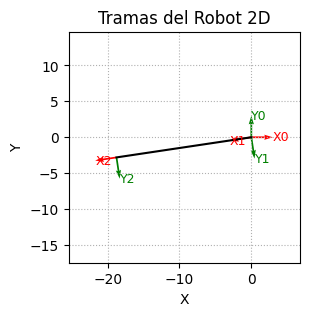

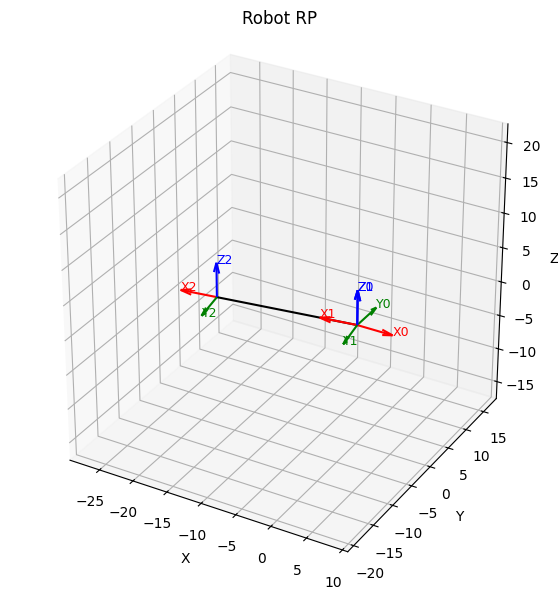

<Axes3D: title={'center': 'Robot RP'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_rp(np.radians(np.random.uniform(0, 360)), np.random.uniform(0, 20))
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot RP")

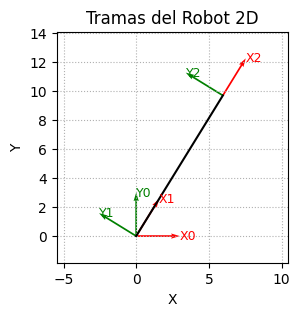

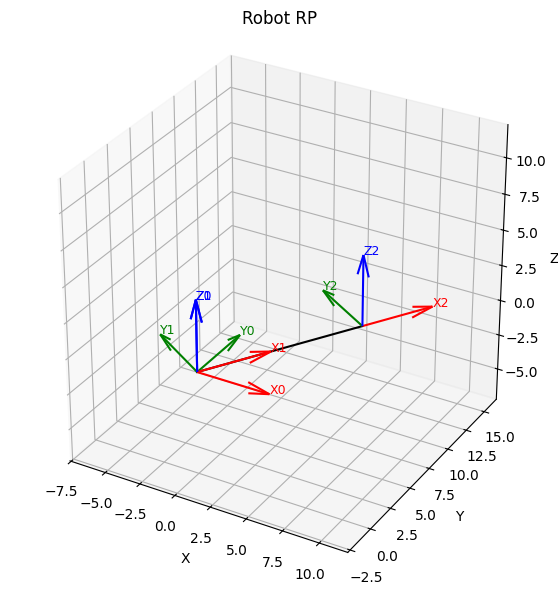

<Axes3D: title={'center': 'Robot RP'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_rp(np.radians(np.random.uniform(0, 360)), np.random.uniform(0, 20))
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot RP")

##RPR
Matrices de transformación homogenea:

$$T_0^1 = \begin{bmatrix} Cos(\theta_1) & -Sen(\theta_1) & 0 & 0\\ Sen(\theta_1) & Cos(\theta_1) & 0 & 0\\ 0 & 0 & 1 &0 \\ 0 & 0 & 0 & 1\end{bmatrix}$$

$$T_1^{2} = \begin{bmatrix} 1 & 0 & 0 &L_1+\theta_2 \\ 0 & 1 & 0 & 0\\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1\end{bmatrix}$$

$$T_2^{3} = \begin{bmatrix} Cos(\theta_3) & -Sen(\theta_3) & 0 & 0 \\ Sen(\theta_3) & Cos(\theta_3) & 0 & 0\\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1\end{bmatrix} $$

$$T_3^{EF} = \begin{bmatrix} 1 & 0 & 0 &L_3 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1\end{bmatrix}$$

Multiplicamos para hallar la cinemática directa del EF respecto al origen (0):
$$T_0^{EF} = T_0^1 \cdot T_1^{2}\cdot T_2^{3}\cdot T_3^{EF}$$

In [ ]:
theta1 = sp.symbols('theta1')
T_01 = sp.Matrix([
    [sp.cos(theta1), -sp.sin(theta1), 0, 0],
    [sp.sin(theta1),  sp.cos(theta1), 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
theta2, L1 = sp.symbols('theta2 L1')
T_12 = sp.Matrix([
    [1, 0, 0, L1+theta2],
    [0, 1, 0, 0],
    [0, 0, 1 , 0],
    [0, 0, 0, 1]
])
theta3 = sp.symbols('theta3')
T_23 = sp.Matrix([
    [sp.cos(theta3), -sp.sin(theta3), 0 , 0],
    [sp.sin(theta3),  sp.cos(theta3), 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
L3 = sp.symbols('L3')
T_3EF = sp.Matrix([
    [1, 0, 0, L3],
    [0, 1, 0, 0],
    [0, 0, 1 ,0],
    [0, 0, 0, 1]
])
print("Matriz homogenea del origen al efector final:")
Tf=trigsimp(T_01*T_12*T_23*T_3EF)
display(Tf)

Matriz homogenea del origen al efector final:


⎡cos(θ₁ + θ₃)  -sin(θ₁ + θ₃)  0  L₃⋅cos(θ₁ + θ₃) + (L₁ + θ₂)⋅cos(θ₁)⎤
⎢                                                                   ⎥
⎢sin(θ₁ + θ₃)  cos(θ₁ + θ₃)   0  L₃⋅sin(θ₁ + θ₃) + (L₁ + θ₂)⋅sin(θ₁)⎥
⎢                                                                   ⎥
⎢     0              0        1                   0                 ⎥
⎢                                                                   ⎥
⎣     0              0        0                   1                 ⎦

In [ ]:
def Rz(theta):
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ])

# ---------------------------------------
# Transformación homogénea general
# ---------------------------------------
def homog(R, p):
    T = np.eye(4)
    T[:3,:3] = R
    T[:3,3] = p
    return T

# ---------------------------------------
# Cinemática directa RPR
# ---------------------------------------
def fk_rpr(theta1, d2, theta3, L1, L2):

    T0 = np.eye(4)

    # Revoluta 1
    T1 = T0 @ homog(Rz(theta1), np.array([0,0,0]))

    # Prismática (se mueve en X del frame 1)
    T2 = T1 @ homog(np.eye(3), np.array([L1 + d2,0,0]))

    # Revoluta 3
    T3 = T2 @ homog(Rz(theta3), np.array([0,0,0]))

    # Último eslabón
    T4 = T3 @ homog(np.eye(3), np.array([L2,0,0]))

    return np.stack([T0, T1, T2, T3, T4], axis=0)

# Parámetros
L1 = 10
L3 = 20



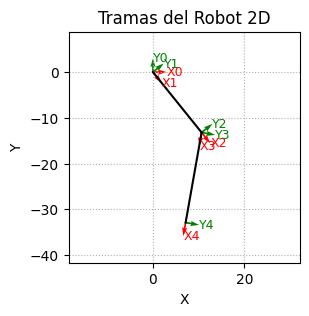

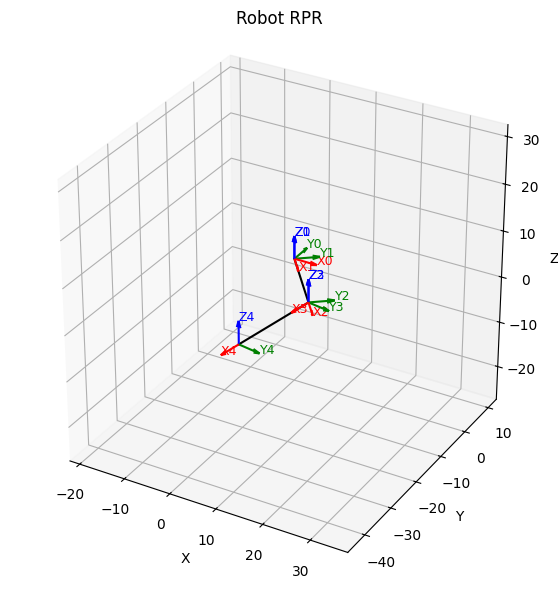

<Axes3D: title={'center': 'Robot RPR'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_rpr(np.radians(np.random.uniform(0, 360)), np.random.uniform(0, 20), np.radians(np.random.uniform(0, 360)), L1, L3)
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot RPR")

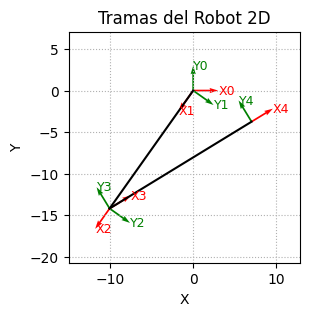

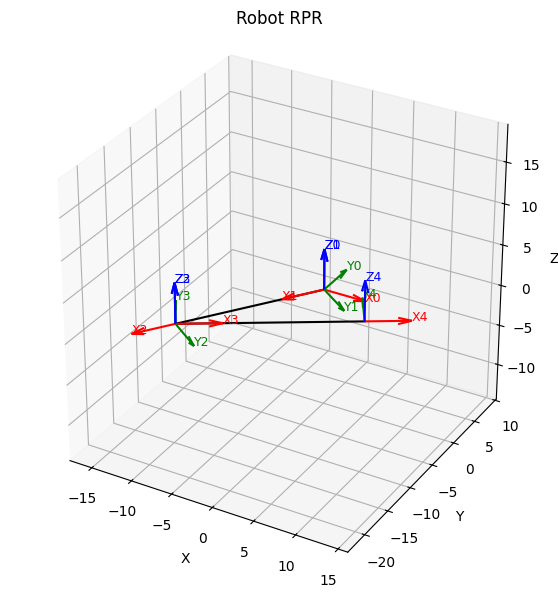

<Axes3D: title={'center': 'Robot RPR'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_rpr(np.radians(np.random.uniform(0, 360)), np.random.uniform(0, 20), np.radians(np.random.uniform(0, 360)), L1, L3)
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot RPR")

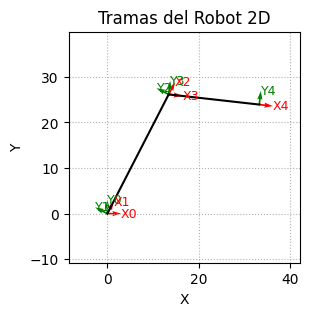

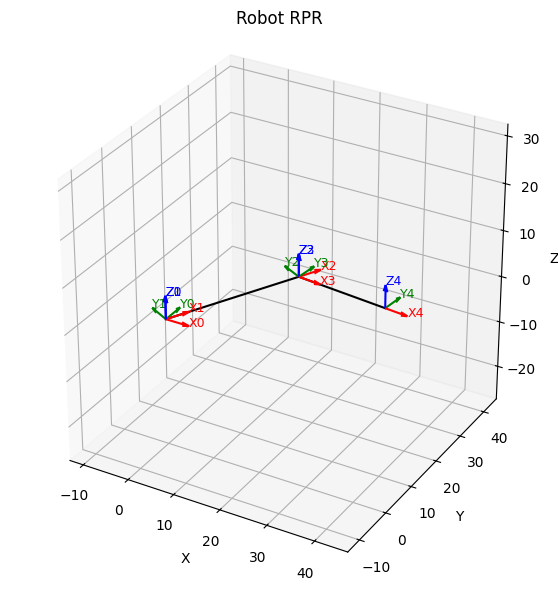

<Axes3D: title={'center': 'Robot RPR'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_rpr(np.radians(np.random.uniform(0, 360)), np.random.uniform(0, 20), np.radians(np.random.uniform(0, 360)), L1, L3)
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot RPR")

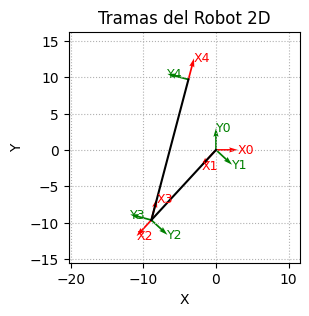

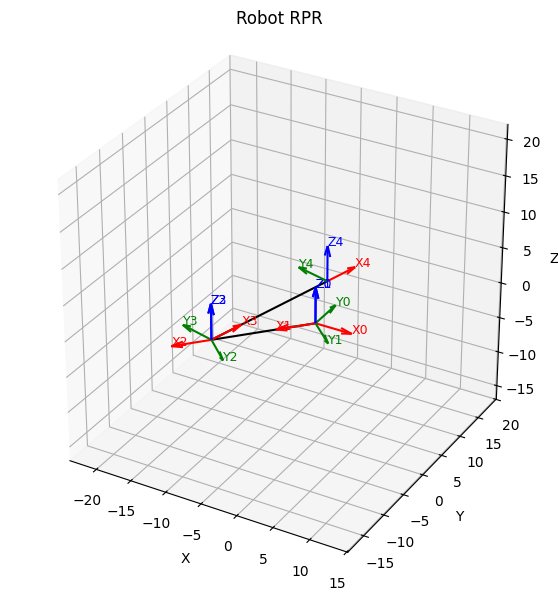

<Axes3D: title={'center': 'Robot RPR'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
Ts = fk_rpr(np.radians(np.random.uniform(0, 360)), np.random.uniform(0, 20), np.radians(np.random.uniform(0, 360)), L1, L3)
plot_frames_xy(Ts, axis_length=3)
plot_frames_3d(Ts, axis_length=5, title="Robot RPR")

##MELFA

In [ ]:
theta1 = sp.symbols('theta1')
T_01 = sp.Matrix([
    [sp.cos(theta1), -sp.sin(theta1), 0, 0],
    [sp.sin(theta1),  sp.cos(theta1), 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
theta2, L1 = sp.symbols('theta2 L1')
T_12 = sp.Matrix([
    [sp.cos(theta2), 0, sp.sin(theta2), 0],
    [0, 1, 0, 0],
    [-sp.sin(theta2), 0, sp.cos(theta2) , L1],
    [0, 0, 0, 1]
])
theta3,L2 = sp.symbols('theta3 L2')
T_23 = sp.Matrix([
    [sp.cos(theta3), 0, sp.sin(theta3), 0],
    [0, 1, 0, 0],
    [-sp.sin(theta3), 0, sp.cos(theta3) , L2],
    [0, 0, 0, 1]
])
theta4, L3 = sp.symbols('theta4 L3')

T_34 = sp.Matrix([
    [sp.cos(theta4), -sp.sin(theta4), 0, 0],
    [sp.sin(theta4), sp.cos(theta4), 0 , 0],
    [0, 0, 1, L3],
    [0, 0, 0, 1]
])
theta5 = sp.symbols('theta5')
T_45 = sp.Matrix([
    [sp.cos(theta5), 0, sp.sin(theta5), 0],
    [0, 1, 0, 0],
    [-sp.sin(theta5), 0, sp.cos(theta5) , 0],
    [0, 0, 0, 1]
])
theta6 = sp.symbols('theta6')
T_56 = sp.Matrix([
    [sp.cos(theta6), -sp.sin(theta6), 0, 0],
    [sp.sin(theta6), sp.cos(theta6), 0 , 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
L4 = sp.symbols('L4')
T_6EF = sp.Matrix([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1 ,L4],
    [0, 0, 0, 1]
])




print("Matriz homogenea del origen al efector final:")
Tf=trigsimp(T_01*T_12*T_23*T_34*T_45*T_56*T_6EF)
display(sp.simplify(Tf))

Matriz homogenea del origen al efector final:


⎡-((sin(θ₁)⋅sin(θ₄) - cos(θ₁)⋅cos(θ₄)⋅cos(θ₂ + θ₃))⋅cos(θ₅) + sin(θ₅)⋅sin(θ₂ + ↪
⎢                                                                              ↪
⎢((sin(θ₁)⋅cos(θ₄)⋅cos(θ₂ + θ₃) + sin(θ₄)⋅cos(θ₁))⋅cos(θ₅) - sin(θ₁)⋅sin(θ₅)⋅s ↪
⎢                                                                              ↪
⎢                                -(sin(θ₅)⋅cos(θ₂ + θ₃) + sin(θ₂ + θ₃)⋅cos(θ₄) ↪
⎢                                                                              ↪
⎣                                                                              ↪

↪  θ₃)⋅cos(θ₁))⋅cos(θ₆) - (sin(θ₁)⋅cos(θ₄) + sin(θ₄)⋅cos(θ₁)⋅cos(θ₂ + θ₃))⋅sin ↪
↪                                                                              ↪
↪ in(θ₂ + θ₃))⋅cos(θ₆) - (sin(θ₁)⋅sin(θ₄)⋅cos(θ₂ + θ₃) - cos(θ₁)⋅cos(θ₄))⋅sin( ↪
↪                                                                              ↪
↪ ⋅cos(θ₅))⋅cos(θ₆) + sin(θ₄)⋅sin(θ₆)⋅sin(θ₂ + θ₃)                             ↪
↪                          

In [ ]:
Tf_n = sp.lambdify([theta1, theta2, theta3, theta4, theta5, theta6, L1, L2, L3, L4],Tf,'numpy')
Tf_n(0,0,0,0,0,0,1,1,1,1)

array([[ 1., -0.,  0.,  0.],
       [ 0.,  1.,  0.,  0.],
       [ 0.,  0.,  1.,  4.],
       [ 0.,  0.,  0.,  1.]])

In [ ]:
display(Tf_n(np.pi/2,0,0,0,0,0,1,1,1,1))
display(Tf_n(0,np.pi/2,0,0,0,0,1,1,1,1))
display(Tf_n(0,0,np.pi/2,0,0,0,1,1,1,1))
display(Tf_n(0,0,0,np.pi/2,0,0,1,1,1,1))
display(Tf_n(0,0,0,0,np.pi/2,0,1,1,1,1))
display(Tf_n(0,0,0,0,0,np.pi/2,1,1,1,1))

array([[ 0., -1.,  0.,  0.],
       [ 1.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  4.],
       [ 0.,  0.,  0.,  1.]])

array([[ 0., -0.,  1.,  3.],
       [ 0.,  1.,  0.,  0.],
       [-1.,  0.,  0.,  1.],
       [ 0.,  0.,  0.,  1.]])

array([[ 0., -0.,  1.,  2.],
       [ 0.,  1.,  0.,  0.],
       [-1.,  0.,  0.,  2.],
       [ 0.,  0.,  0.,  1.]])

array([[ 0., -1.,  0.,  0.],
       [ 1.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  4.],
       [ 0.,  0.,  0.,  1.]])

array([[ 0., -0.,  1.,  1.],
       [ 0.,  1.,  0.,  0.],
       [-1.,  0.,  0.,  3.],
       [ 0.,  0.,  0.,  1.]])

array([[ 0., -1.,  0.,  0.],
       [ 1.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  4.],
       [ 0.,  0.,  0.,  1.]])

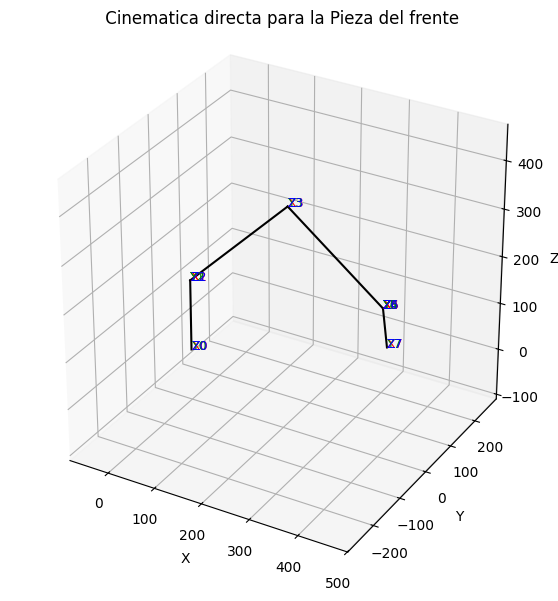

array([[  0.993,  -0.051,   0.11 , 417.38 ],
       [ -0.053,  -0.998,   0.019,  -2.8  ],
       [  0.109,  -0.024,  -0.994, 131.54 ],
       [  0.   ,   0.   ,   0.   ,   1.   ]])

Ángulos en radianes:
[-0.011 -0.793  1.449  3.113  0.767 -3.078]
Ángulos en grados:
[  -0.603  -45.414   83.038  178.355   43.94  -176.373]


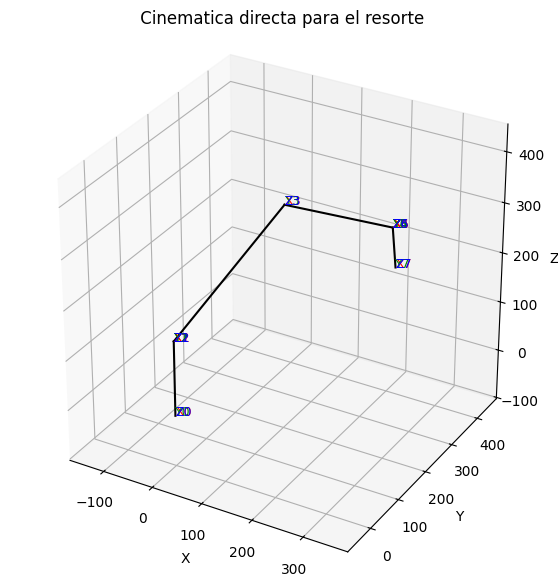

array([[ -0.095,  -0.993,   0.076, 215.66 ],
       [ -0.995,   0.098,   0.024, 397.31 ],
       [ -0.031,  -0.074,  -0.997, 161.31 ],
       [  0.   ,   0.   ,   0.   ,   1.   ]])

Ángulos en radianes:
[ 1.083 -0.733  1.188 -3.027  0.514 -0.492]
Ángulos en grados:
[  62.077  -42.014   68.052 -173.429   29.447  -28.197]


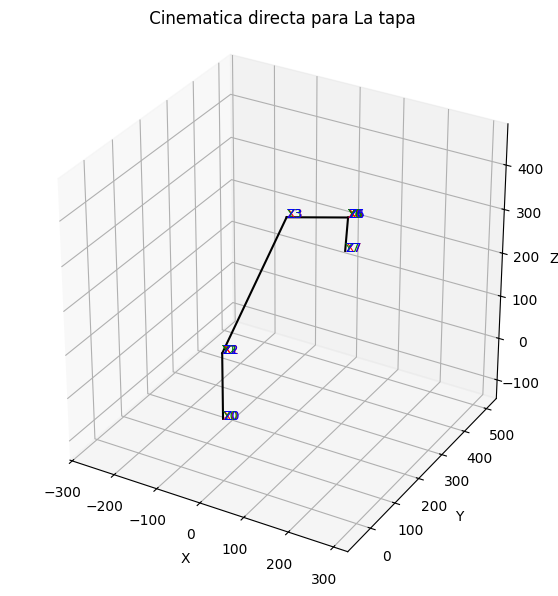

array([[  0.499,   0.863,  -0.079,  19.57 ],
       [  0.866,  -0.5  ,   0.011, 454.6  ],
       [ -0.03 ,  -0.074,  -0.997, 162.48 ],
       [  0.   ,   0.   ,   0.   ,   1.   ]])

Ángulos en radianes:
[ 1.514 -0.712  1.141  2.955  0.441 -2.505]
Ángulos en grados:
[  86.736  -40.809   65.349  169.302   25.279 -143.552]


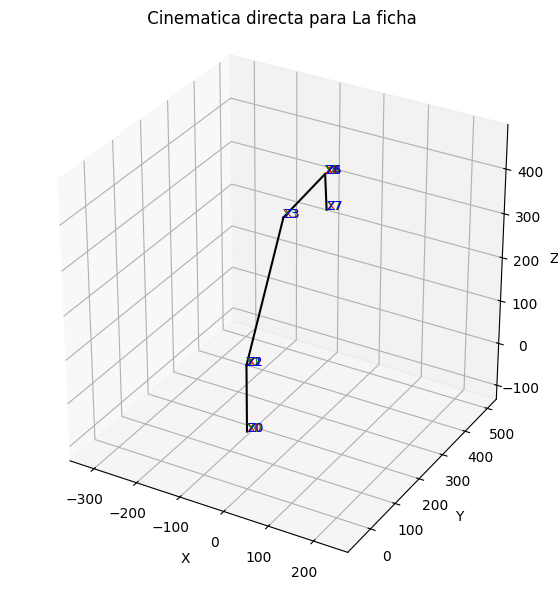

array([[ -0.915,  -0.399,   0.058, -77.82 ],
       [ -0.401,   0.916,  -0.015, 449.74 ],
       [ -0.047,  -0.037,  -0.998, 256.96 ],
       [  0.   ,   0.   ,   0.   ,   1.   ]])

Ángulos en radianes:
[ 1.752 -0.796  0.906 -2.57   0.1    0.771]
Ángulos en grados:
[ 100.361  -45.583   51.891 -147.234    5.75    44.176]


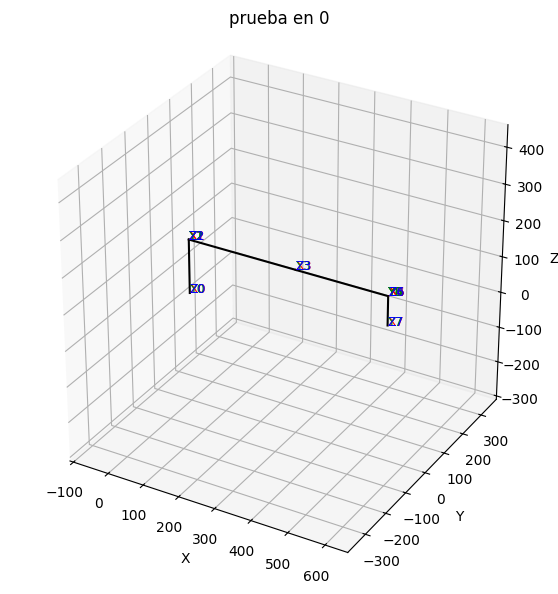

array([[  1.,   0.,   0., 550.],
       [  0.,  -1.,   0.,   0.],
       [  0.,  -0.,  -1.,  70.],
       [  0.,   0.,   0.,   1.]])

Ángulos en radianes:
[0, 0, 0, 0, 0, 0]
Ángulos en grados:
[0. 0. 0. 0. 0. 0.]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def make_chain_MELFA(q_1, q_2, q_3, q_4, q_5, q_6, L1, L2, L3, L4):
    def _rotz(th):
        c, s = np.cos(th), np.sin(th)
        T = np.eye(4)
        T[:3, :3] = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
        return T

    def _rotx(al):
        c, s = np.cos(al), np.sin(al)
        T = np.eye(4)
        T[:3, :3] = np.array([[1, 0, 0], [0, c, -s], [0, s, c]])
        return T

    def _transx(a):
        T = np.eye(4); T[0, 3] = a; return T

    def _transz(d):
        T = np.eye(4); T[2, 3] = d; return T

    def _A_mdh(alpha_prev, a_prev, theta_i, d_i):
        return _rotx(alpha_prev) @ _transx(a_prev) @ _rotz(theta_i) @ _transz(d_i)

    thetas  = [q_1,      q_2,  q_3,      q_4,      q_5,      q_6,  0.0]
    ds      = [L1,       0.0,  0.0,      0.0,      0.0,      0.0,  L4 ]
    a_prevs = [0.0,      0.0,   L2,       L3,      0.0,      0.0,  0.0]
    alphas  = [0.0, -np.pi/2,  0.0,  -np.pi/2, np.pi/2, -np.pi/2,  0.0]

    T0 = np.eye(4)
    Ts = [T0]
    T = T0.copy()

    for th, d, a, al in zip(thetas, ds, a_prevs, alphas):
        T = T @ _A_mdh(al, a, th, d)
        Ts.append(T)

    return np.stack(Ts, axis=0)


def plot_frames_3d(T_list, axis_length=0.1, link_tol=1e-12, ax=None, show=True, title=None):
    T_arr = np.asarray(T_list)
    if T_arr.ndim != 3 or T_arr.shape[1:] != (4, 4):
        raise ValueError("T_list debe ser de forma (N,4,4).")

    created_ax = False
    if ax is None:
        fig = plt.figure(figsize=(7, 7))
        ax = fig.add_subplot(111, projection='3d')
        created_ax = True

    origins = T_arr[:, :3, 3]
    x_dirs  = T_arr[:, :3, 0]
    y_dirs  = T_arr[:, :3, 1]
    z_dirs  = T_arr[:, :3, 2]

    for i in range(T_arr.shape[0]):
        ox, oy, oz = origins[i]
        dx, dy, dz = axis_length * x_dirs[i]
        ux, uy, uz = axis_length * y_dirs[i]
        wx, wy, wz = axis_length * z_dirs[i]

        ax.quiver(ox, oy, oz, dx, dy, dz, length=1.0, normalize=False, color='r')
        ax.text(ox + dx, oy + dy, oz + dz, f"X{i}", color='r', fontsize=9)
        ax.quiver(ox, oy, oz, ux, uy, uz, length=1.0, normalize=False, color='g')
        ax.text(ox + ux, oy + uy, oz + uz, f"Y{i}", color='g', fontsize=9)
        ax.quiver(ox, oy, oz, wx, wy, wz, length=1.0, normalize=False, color='b')
        ax.text(ox + wx, oy + wy, oz + wz, f"Z{i}", color='b', fontsize=9)

    for i in range(1, origins.shape[0]):
        p0 = origins[i - 1]
        p1 = origins[i]
        if np.linalg.norm(p1 - p0) > link_tol:
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], 'k-')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    all_pts = np.vstack([
        origins,
        origins + axis_length * x_dirs,
        origins + axis_length * y_dirs,
        origins + axis_length * z_dirs
    ])
    mins = all_pts.min(axis=0)
    maxs = all_pts.max(axis=0)
    center = (mins + maxs) / 2.0
    span = (maxs - mins).max()
    if span <= 0:
        span = axis_length * 2
    margin = 0.2 * span
    ax.set_xlim(center[0] - span/2 - margin, center[0] + span/2 + margin)
    ax.set_ylim(center[1] - span/2 - margin, center[1] + span/2 + margin)
    ax.set_zlim(center[2] - span/2 - margin, center[2] + span/2 + margin)

    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass

    if title:
        ax.set_title(title)

    if created_ax and show:
        plt.show()
    return ax


def C_Directa(ang, L_ar, message):
    Ts = make_chain_MELFA(ang[0], ang[1], ang[2], ang[3], ang[4], ang[5],
                          L_ar[0], L_ar[1], L_ar[2], L_ar[3])
    np.set_printoptions(precision=3, suppress=True)
    plot_frames_3d(Ts, axis_length=0.08, title=message)
    display(Ts[-1])
    print("Ángulos en radianes:")
    print(ang)
    print("Ángulos en grados:")
    print(np.rad2deg(ang))


def matriz_rotacion_ABC(A_deg, B_deg, C_deg):
    A, B, C = np.deg2rad([A_deg, B_deg, C_deg])

    Rx = np.array([[1, 0, 0],
                   [0, np.cos(A), -np.sin(A)],
                   [0, np.sin(A),  np.cos(A)]])

    Ry = np.array([[ np.cos(B), 0, np.sin(B)],
                   [0, 1, 0],
                   [-np.sin(B), 0, np.cos(B)]])

    Rz = np.array([[np.cos(C), -np.sin(C), 0],
                   [np.sin(C),  np.cos(C), 0],
                   [0, 0, 1]])

    return Rz @ Ry @ Rx


def calcular_centro_muneca(posicion_TCP, R06, L4):
    pE6 = np.array([0, 0, L4])
    centro_muneca = posicion_TCP - R06 @ pE6
    return centro_muneca


def resolver_posicion(centro_muneca, L1, L2, L3, codo_arriba=True):
    x, y, z = centro_muneca

    q1 = np.arctan2(y, x)

    r = np.sqrt(x**2 + y**2)
    s = z - L1

    D = (r**2 + s**2 - L2**2 - L3**2) / (2 * L2 * L3)
    D = np.clip(D, -1.0, 1.0)

    signo = 1.0 if codo_arriba else -1.0
    q3_geo = np.arctan2(signo * np.sqrt(1 - D**2), D)
    q2_geo = np.arctan2(s, r) - np.arctan2(L3 * np.sin(q3_geo),
                                            L2 + L3 * np.cos(q3_geo))

    # El DH del modelo tiene q2 y q3 con signo opuesto a la geometria
    return q1, -q2_geo, -q3_geo


def resolver_orientacion(R03, R06):
    # Derivado simbolicamente de la estructura MDH:
    # R36 = [Rx(-pi/2)@Rz(q4)] @ [Rx(pi/2)@Rz(q5)] @ [Rx(-pi/2)@Rz(q6)]
    # R36[1,2] = cos(q5)
    # R36[1,0] = sin(q5)*cos(q6),  R36[1,1] = -sin(q5)*sin(q6)
    # R36[0,2] = -sin(q5)*cos(q4), R36[2,2] =  sin(q4)*sin(q5)
    R36 = R03.T @ R06

    q5 = np.arccos(np.clip(R36[1, 2], -1.0, 1.0))
    sin_q5 = np.sin(q5)

    if abs(sin_q5) > 1e-6:
        q4 = np.arctan2( R36[2, 2], -R36[0, 2])
        q6 = np.arctan2(-R36[1, 1],  R36[1, 0])
    else:
        q4 = 0.0
        q6 = np.arctan2(-R36[0, 1], R36[0, 0])

    return q4, q5, q6


def cinematica_inversa_MELFA(X, Y, Z, A, B, C, L1, L2, L3, L4, funcion_directa, codo_arriba=False):
    R06 = matriz_rotacion_ABC(A, B, C)
    posicion_TCP = np.array([X, Y, Z])

    centro_muneca = calcular_centro_muneca(posicion_TCP, R06, L4)

    q1, q2, q3 = resolver_posicion(centro_muneca, L1, L2, L3, codo_arriba)

    Ts = funcion_directa(q1, q2, q3, 0, 0, 0, L1, L2, L3, L4)
    R03 = Ts[3][:3, :3]

    q4, q5, q6 = resolver_orientacion(R03, R06)

    angulos = np.array([q1, q2, q3, q4, q5, q6])

    Ts_check = funcion_directa(q1, q2, q3, q4, q5, q6, L1, L2, L3, L4)
    T_ef = Ts_check[-1]

    return angulos


Ls = [150, 300, 250, 80]

xyz_1 = [417.38, -2.80, 131.54]
ABC_1 = [-178.59, -6.25, -3.06]

angulos = cinematica_inversa_MELFA(
    X=xyz_1[0], Y=xyz_1[1], Z=xyz_1[2],
    A=ABC_1[0], B=ABC_1[1], C=ABC_1[2],
    L1=Ls[0], L2=Ls[1], L3=Ls[2], L4=Ls[3],
    funcion_directa=make_chain_MELFA
)
ms = " Cinematica directa para la Pieza del frente"
C_Directa(angulos, Ls, ms)


xyz_2 = [215.66, 397.31, 161.31]
ABC_2 = [-175.78, 1.77, -95.48]

angulos = cinematica_inversa_MELFA(
    X=xyz_2[0], Y=xyz_2[1], Z=xyz_2[2],
    A=ABC_2[0], B=ABC_2[1], C=ABC_2[2],
    L1=Ls[0], L2=Ls[1], L3=Ls[2], L4=Ls[3],
    funcion_directa=make_chain_MELFA
)
ms = " Cinematica directa para el resorte"
C_Directa(angulos, Ls, ms)


xyz_3 = [19.57, 454.60, 162.48]
ABC_3 = [-175.78, 1.73, 60.06]

angulos = cinematica_inversa_MELFA(
    X=xyz_3[0], Y=xyz_3[1], Z=xyz_3[2],
    A=ABC_3[0], B=ABC_3[1], C=ABC_3[2],
    L1=Ls[0], L2=Ls[1], L3=Ls[2], L4=Ls[3],
    funcion_directa=make_chain_MELFA
)
ms = " Cinematica directa para La tapa"
C_Directa(angulos, Ls, ms)


xyz_4 = [-77.82, 449.74, 256.96]
ABC_4 = [-177.86, 2.69, -156.36]

angulos = cinematica_inversa_MELFA(
    X=xyz_4[0], Y=xyz_4[1], Z=xyz_4[2],
    A=ABC_4[0], B=ABC_4[1], C=ABC_4[2],
    L1=Ls[0], L2=Ls[1], L3=Ls[2], L4=Ls[3],
    funcion_directa=make_chain_MELFA
)
ms = " Cinematica directa para La ficha"
C_Directa(angulos, Ls, ms)


ag0 = [0, 0, 0, 0, 0, 0]
ms = "prueba en 0"
C_Directa(ag0, Ls, ms)